In [40]:
# --- Setup: base imports ---
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inspect
import html
from IPython.display import display, HTML

# --- Setup: project path ---
# If the notebook is in L2_Regression/notebooks,
# this adds L2_Regression to PYTHONPATH
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


# Optional (recommended) for syntax highlighting
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter
# Inject CSS once
_PYGMENTS_CSS_LOADED = False

def show_full_function(func, name=None):
    global _PYGMENTS_CSS_LOADED
    
    name = name or func.__name__
    source = inspect.getsource(func)

    # Syntax highlight HTML
    formatter = HtmlFormatter(style="friendly", noclasses=False)
    highlighted = highlight(source, PythonLexer(), formatter)

    # Load CSS only once
    if not _PYGMENTS_CSS_LOADED:
        css = formatter.get_style_defs('.highlight')
        display(HTML(f"<style>{css}</style>"))
        _PYGMENTS_CSS_LOADED = True

    html_block = f"""
    <details>
      <summary><strong>View full function: {html.escape(name)}</strong></summary>
      {highlighted}
    </details>
    """
    display(HTML(html_block))

# --- Imports from single_level_production (Simple_Polynomials) ---
from Simple_Polynomials.single_level_production import (
    GBM_paths,
    normaleq_components,
    fit_local_vol,
    make_b_bar,
    plot_localvol,
    plot_logreturns,
)  
# --- Imports from weak_error_analysis (Simple_Polynomials)
from Simple_Polynomials.weak_error_analysis import (
    GBM_paths as we_GBM_paths,
    normaleq_components as we_normaleq_components,
    fit_local_vol as we_fit_local_vol,
    make_b_bar as we_make_b_bar,
    plot_localvol as we_plot_localvol,
    plot_weakerror,
)

<h1 style="text-align: center;">Single Level $L^2$ Regression using Markovian Projection</h1>

This notebook documents the implementation in `Simple_Polynomials/single_level_production.py`. It studies the same correlated Black--Scholes basket and Markovian projection framework as `nb02_L2Regression_single_level.ipynb`, but with a different regression architecture: `nb02` follows `Rough_programs/DesignMatrix_refactored.py` and uses an orthonormal **Legendre polynomial basis**, whereas the present notebook follows `single_level_production.py` and uses **simple rescaled monomials** such as $\{1,s_c,s_c^2,t_c\}$. Thus, the stochastic model is essentially the same, but the approximation space and implementation style are simpler here, making this notebook a monomial baseline for comparison.


## Black-Scholes Correlated Model:
$$
dX(t)=a(t,X(t))\,dt + b(t,X(t))\,dW(t), \qquad 0<t<T,\quad X(t)\in\mathbb{R}^d,\quad W(t)\ \text{is a $k$-dim.\ Brownian motion}.
$$
$$
X(0)=x_0.
$$

- $a(t,x)=r\,x,\qquad r=0.05.$  
- $b(t,x)\in\mathbb{R}^{d\times k}.$  
- $P_1=(1,1,1)$

Also,
$$
\Sigma=
\begin{pmatrix}
1 & 0.8 & 0.3\\
0.8 & 1 & 0.1\\
0.3 & 0.1 & 1
\end{pmatrix},
\qquad
GG^\top=\Sigma,
\qquad
\sigma=(0.2,\ 0.15,\ 0.1)^\top.
$$

A convenient implementation is
$$
dX(t)=rX(t)\,dt+\operatorname{diag}(X(t))\,\operatorname{diag}(\sigma)\,G\,dW(t).
$$
Componentwise, this means
$$
dX_i(t)=rX_i(t)\,dt+\sigma_i X_i(t)\sum_{j=1}^{k}G_{ij}\,dW_j(t).
$$

Even if the Brownian components $W_1,\dots,W_k$ are independent, the assets are correlated because they share the same factors through the matrix $G$. The return covariance structure is determined by
$$
\operatorname{diag}(\sigma)\,GG^\top\,\operatorname{diag}(\sigma)
=
\operatorname{diag}(\sigma)\,\Sigma\,\operatorname{diag}(\sigma).
$$

### Example ($d=3$)

Let $x=(x_1,x_2,x_3)^\top$. Then the diffusion matrix is
$$
b_{\mathrm{BS}}(t,x)=\operatorname{diag}(x)\,\operatorname{diag}(\sigma)\,G,
$$
so each component satisfies
$$
\left\{
\begin{aligned}
dX_1(t) &= rX_1(t)\,dt
+ \sigma_1 X_1(t)\Big(G_{11}\,dW_1(t)+G_{12}\,dW_2(t)+G_{13}\,dW_3(t)\Big),\\[2mm]
dX_2(t) &= rX_2(t)\,dt
+ \sigma_2 X_2(t)\Big(G_{21}\,dW_1(t)+G_{22}\,dW_2(t)+G_{23}\,dW_3(t)\Big),\\[2mm]
dX_3(t) &= rX_3(t)\,dt
+ \sigma_3 X_3(t)\Big(G_{31}\,dW_1(t)+G_{32}\,dW_2(t)+G_{33}\,dW_3(t)\Big).
\end{aligned}
\right.
$$

## Non-Markovian Process

Let
$$
S(t)=P_1 X(t),
$$
with $P_1\in\mathbb{R}^{1\times d}$ and $X(t)\in\mathbb{R}^{d\times 1}$.

Although $X(t)$ is Markovian, the scalar basket $S(t)$ is in general **not** Markovian by itself.  
We therefore introduce a one-dimensional Markov surrogate $\bar S^{(x_0)}(t)$:
$$
\left\{
\begin{aligned}
d\bar S^{(x_0)}(t) &= \bar a^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,dt
+ \bar b^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,d\bar W(t), \qquad t\in[0,T],\\
\bar S^{(x_0)}(0) &= P_1x_0.
\end{aligned}
\right.
$$

The projected drift and diffusion are defined by conditional expectations:
$$
\bar a^{(x_0)}(t,s)
=
\mathbb{E}\!\left[\,P_1 a\!\bigl(t,X(t)\bigr)\ \middle|\ P_1X(t)=s,\ X(0)=x_0\,\right]
=rs,
$$
and
$$
\bigl(\bar b^{(x_0)}(t,s)\bigr)^2
=
\mathbb{E}\!\left[
P_1\,b\!\bigl(t,X(t)\bigr)\,b\!\bigl(t,X(t)\bigr)^\top P_1^\top
\ \middle|\ P_1X(t)=s,\ X(0)=x_0
\right].
$$

For the correlated Black-Scholes diffusion,
$$
b_{\mathrm{BS}}(t,x)=\operatorname{diag}(x)\,\operatorname{diag}(\sigma)\,G,
$$
hence
$$
b_{\mathrm{BS}}(t,x)b_{\mathrm{BS}}(t,x)^\top
=
\operatorname{diag}(x)\,\operatorname{diag}(\sigma)\,\Sigma\,\operatorname{diag}(\sigma)\,\operatorname{diag}(x).
$$

Therefore, for equal weights $P_1=\frac1d(1,\dots,1)$,
$$
P_1\,b_{\mathrm{BS}}(t,x)b_{\mathrm{BS}}(t,x)^\top P_1^\top
=
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,x_i x_j\,\Sigma_{ij}.
$$

Replacing $x$ by $X(t)$ and conditioning on $S(t)=P_1X(t)=s$ gives
$$
\bigl(\bar b^{(x_0)}(t,s)\bigr)^2
=
\mathbb{E}\!\left[
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i(t)\,X_j(t)\,\Sigma_{ij}
\ \middle|\ S(t)=s,\ X(0)=x_0
\right].
$$

This is the quantity we approximate numerically.

## $L^2$ Regression Problem with Simple Polynomial Basis

We approximate $\bigl(\bar b^{(x_0)}\bigr)^2(t,s)$ by solving a discrete $L^2$ regression problem over a finite-dimensional space of **simple monomials**.

After rescaling time and basket values,
$$
t_c=\frac{t-\mu_t}{\sigma_t},
\qquad
s_c=\frac{s-\mu_s}{\sigma_s},
$$
we choose basis functions of the form
$$
\psi_{(i_1,i_2)}(t,s)=t_c^{\,i_1}s_c^{\,i_2}.
$$

In the reference implementation, the chosen basis is
$$
\{1,\ s_c,\ s_c^2,\ t_c\},
$$
corresponding to the index pairs
$$
(0,0),\ (0,1),\ (0,2),\ (1,0).
$$

Hence we approximate the projected variance by
$$
\tilde b^2(t,s)
=
c_0 + c_1 s_c + c_2 s_c^2 + c_3 t_c.
$$

Given simulated paths $\{X^{(m)}(t_n)\}$, we solve
$$
\min_{c\in\mathbb{R}^P}
\frac{1}{M}\sum_{m=1}^{M}\frac{1}{N}\sum_{n=1}^{N}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,\Sigma_{ij}
-
\sum_{p=1}^{P} c_p\,\psi_p(t_n,P_1X^{(m)}(t_n))
\right)^2.
$$

This leads to a linear least-squares problem
$$
Dc\approx \psi,
$$
where:
- $D$ is the design matrix built from the monomial basis,
- $\psi$ is the vector of true instantaneous basket variances,
- $c$ contains the fitted coefficients.

Finally, the projected volatility is defined by
$$
\bar b(t,s)=\sqrt{\tilde b^2(t,s)}.
$$

<h1 style="text-align: center;">Implementation</h1>

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 1: Define the market parameters and generate training paths
</h4>

We begin by fixing the market and simulation parameters of the correlated Black--Scholes basket model, and then simulate training paths of the full $d$-dimensional process.

The dynamics are
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\,(G\,dW(t))_i,
\qquad i=1,\dots,d,
$$
where:
- $r$ is the risk-free rate,
- $\sigma_i$ is the volatility of asset $i$,
- $G$ is the Cholesky factor of the correlation matrix $\Sigma$, so that
  $$
  GG^\top=\Sigma.
  $$

In this example:
- the basket has $d=3$ assets,
- the basket weights are equal,
  $$
  P_1=\frac{1}{3}(1,1,1)^\top,
  $$
- the volatilities are
  $$
  \sigma=(0.2,\ 0.15,\ 0.1)^\top,
  $$
- and the correlation matrix is
  $$
  \Sigma=
  \begin{pmatrix}
  1 & 0.8 & 0.3\\
  0.8 & 1 & 0.1\\
  0.3 & 0.1 & 1
  \end{pmatrix}.
  $$

We also choose the simple polynomial basis used later for the regression:
$$
\{1,\ s_c,\ s_c^2,\ t_c\},
$$
corresponding to the index pairs
$$
(0,0),\ (0,1),\ (0,2),\ (1,0).
$$

Once these quantities are fixed, we generate $M_t$ correlated sample paths of the $d$-dimensional process on the time grid
$$
t_n=n\Delta t,\qquad n=0,\dots,N_t-1.
$$

The purpose of these simulated paths is to create the training data from which the projected variance will later be estimated.

<details>
<summary><strong>View function used (syntax + explanation): GBM_paths</strong></summary>

**Function:** `GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t)`

**Location:** `L2_Regression/Simple_Polynomials/single_level_production.py`

**What it does:**
- Simulates $M_t$ correlated geometric Brownian motion paths for the $d$ assets.
- Uses the Cholesky factor of the correlation matrix to generate correlated Gaussian shocks.
- Evolves all paths simultaneously using a vectorized Euler--Maruyama update.
- Returns an array of shape `(M_t, N_t, d)` containing the simulated asset paths.

<pre><code>paths = GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t)</code></pre>

</details>

In [5]:
show_full_function(GBM_paths)

In [6]:
# Step 1: market parameters + basis + training paths

# Basket parameters
d = 3
P1 = np.ones(d) / d

# Polynomial basis: {1, s, s^2, t}
pairs = [(0, 0), (0, 1), (0, 2), (1, 0)]
P = len(pairs)

# Market parameters
r = 0.05
x0 = np.linspace(225, 275, num=d)[:, np.newaxis]
vol = np.array([0.2, 0.15, 0.1])
cov_mat = np.array([
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.1],
    [0.3, 0.1, 1.0]
])

# Simulation parameters
dt = 0.005
N_t = 200
M_t = 200

t = np.linspace(0, N_t * dt, num=N_t)

# Generate training paths
paths = GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t)

print("\n--- Step 1 summary ---")
print("d =", d)
print("P1 =", P1)
print("basis pairs =", pairs)
print("number of basis functions =", P)
print("paths shape =", paths.shape)
print("time grid shape =", t.shape)
print("first path, first time step =", paths[0, 0, :])


--- Step 1 summary ---
d = 3
P1 = [0.33333333 0.33333333 0.33333333]
basis pairs = [(0, 0), (0, 1), (0, 2), (1, 0)]
number of basis functions = 4
paths shape = (200, 200, 3)
time grid shape = (200,)
first path, first time step = [225. 250. 275.]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 2: Build the regression matrix $D$ and the response vector $\psi$
</h4>

After simulating the training paths, we now construct the discrete regression problem used to approximate the projected variance.

The objective is to fit a function of the form
$$
\tilde b^2(t,s)=\sum_{p=1}^{P} c_p\,\psi_p(t,s),
$$
where the basis functions are simple monomials in the rescaled variables:
$$
\psi_p(t,s)=t_c^{\,i_1}s_c^{\,i_2},
\qquad
t_c=\frac{t-\mu_t}{\sigma_t},
\qquad
s_c=\frac{s-\mu_s}{\sigma_s}.
$$

Here:
- $t_c$ is the centered and normalized time variable,
- $s_c$ is the centered and normalized basket value,
- $(i_1,i_2)$ runs over the chosen polynomial index pairs.

For each simulated path $m$ and each time step $n$, we define the basket value
$$
S^{(m)}(t_n)=P_1^\top X^{(m)}(t_n).
$$

Then we flatten all path-time pairs into a single index, and construct:

### 1. The design matrix

The design matrix
$$
D\in\mathbb{R}^{(M_tN_t)\times P}
$$
contains the basis functions evaluated at each simulated point:
$$
D_{k,p}=\psi_p(t_n,S^{(m)}(t_n)),
\qquad k\leftrightarrow (m,n).
$$

So each row of $D$ corresponds to one simulated observation, and each column corresponds to one polynomial basis function.

### 2. The response vector

The target vector
$$
\psi\in\mathbb{R}^{M_tN_t}
$$
contains the true instantaneous basket variance at each simulated point.

For the correlated Black--Scholes model, with equal-weight basket weights, this variance is
$$
\psi_{m,n}
=
P_1^\top
\operatorname{diag}(\sigma\odot X^{(m)}(t_n))
\Sigma
\operatorname{diag}(\sigma\odot X^{(m)}(t_n))
P_1.
$$

Since in this example $P_1=\frac1d(1,\dots,1)^\top$, this becomes
$$
\psi_{m,n}
=
\frac{1}{d^2}
\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,\Sigma_{ij}.
$$

This vector is the right-hand side of the discrete $L^2$ regression problem
$$
\min_{c\in\mathbb{R}^P}\|Dc-\psi\|_2^2.
$$

The function in this step returns:
- the design matrix $D$,
- the response vector $\psi$,
- and the scaling parameters $(\mu_t,\sigma_t,\mu_s,\sigma_s)$ needed later when evaluating the fitted projected volatility.

<details>
<summary><strong>View function used (syntax + explanation): normaleq_components</strong></summary>

**Function:** `normaleq_components(paths, P1, pairs, dt, cov_mat, vol)`

**Location:** `L2_Regression/Simple_Polynomials/single_level_production.py`

**What it does:**
- Computes the basket values along all simulated paths.
- Rescales time and basket values using their empirical mean and standard deviation.
- Builds the design matrix $D$ by evaluating the simple monomial basis at each simulated point.
- Computes the response vector $\psi$ as the true instantaneous basket variance.
- Returns `D`, `psi`, and the scaling parameters needed later to define $\bar b(t,s)$.

<pre><code>D, psi, scalers = normaleq_components(paths, P1, pairs, dt, cov_mat, vol)</code></pre>

</details>

In [7]:
show_full_function(normaleq_components)

In [8]:
# Step 2: build regression matrix and response vector
D, psi, scalers = normaleq_components(paths, P1, pairs, dt, cov_mat, vol)

t_mean, t_std, s_mean, s_std = scalers

print("\n--- Step 2 summary ---")
print("D shape:", D.shape)
print("psi shape:", psi.shape)
print("scalers =", scalers)
print("first row of D:", D[0])
print("first entries of psi:", psi[:5].ravel())


--- Step 2 summary ---
D shape: (40000, 4)
psi shape: (40000, 1)
scalers = (np.float64(0.5), np.float64(0.29012213681716326), np.float64(254.6955585963946), np.float64(21.414719736566546))
first row of D: [ 1.         -0.21926781  0.04807837 -1.7234121 ]
first entries of psi: [870.69444444 884.43225732 886.00521216 879.99289118 879.6967715 ]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 3: Solve the $L^2$ regression problem
</h4>

At this point, we have already constructed:
- the design matrix
  $$
  D\in\mathbb{R}^{(M_tN_t)\times P},
  $$
- and the response vector
  $$
  \psi\in\mathbb{R}^{M_tN_t}.
  $$

We now solve the least-squares problem
$$
\min_{c\in\mathbb{R}^{P}} \|Dc-\psi\|_2^2,
$$
where $c=(c_1,\dots,c_P)$ is the vector of coefficients of the polynomial approximation.

The fitted projected variance is therefore
$$
\tilde b^2(t,s)=\sum_{p=1}^{P} c_p\,\psi_p(t,s),
$$
with basis functions
$$
\psi_p(t,s)=t_c^{\,i_1}s_c^{\,i_2}.
$$

### Why this is a least-squares problem

The system is typically overdetermined:
- there are many simulated observations ($M_tN_t$ rows),
- but only a small number of unknown coefficients ($P$).

So in general, we cannot solve
$$
Dc=\psi
$$
exactly. Instead, we choose the coefficient vector $c$ that minimizes the Euclidean residual
$$
\|Dc-\psi\|_2.
$$

This is the discrete version of the $L^2$ projection problem introduced earlier.

A classical way to solve least squares is through the normal equations
$$
D^\top D\,c = D^\top \psi.
$$
However, forming $D^\top D$ can worsen conditioning.

Instead, the code uses a QR decomposition:
$$
D=QR,
$$
where:
- $Q$ has orthonormal columns,
- $R$ is upper triangular.

Substituting into the regression problem gives
$$
QRc \approx \psi.
$$
Multiplying by $Q^\top$ yields
$$
Rc = Q^\top \psi.
$$

So the algorithm is:
1. compute the reduced QR decomposition of $D$,
2. form
   $$
   \alpha = Q^\top \psi,
   $$
3. solve the triangular system
   $$
   Rc=\alpha.
   $$

This gives the fitted coefficient vector $c$.

This is the step where the simulated path data is converted into a parametric approximation of the projected variance.

- Step 1 generated the data,
- Step 2 built the regression problem,
- Step 3 extracts the actual polynomial coefficients.

These coefficients are the numerical representation of the projected variance surface, and in the next step they will be turned into the callable function $\bar b(t,s)$.

<details>
<summary><strong>View function used (syntax + explanation): fit_local_vol</strong></summary>

**Function:** `fit_local_vol(D, psi)`

**Location:** `L2_Regression/Simple_Polynomials/single_level_production.py`

**What it does:**
- Solves the least-squares problem
  $$
  \min_c \|Dc-\psi\|_2^2
  $$
  using QR decomposition.
- Computes:
  - `Q, R = np.linalg.qr(D, mode='reduced')`,
  - `alpha = Q.T @ psi`,
  - `c = np.linalg.solve(R, alpha)`.
- Returns the fitted coefficient vector `c`.
- Also prints diagnostics such as:
  - absolute residual,
  - relative residual,
  - condition number of `D`,
  - smallest singular values.

<pre><code>c = fit_local_vol(D, psi)</code></pre>

</details>

In [10]:
show_full_function(fit_local_vol)

In [11]:
# Step 3: solve the L2 regression problem
c = fit_local_vol(D, psi)

print("\n--- Step 3 summary ---")
print("c shape:", c.shape)
print("number of coefficients:", len(c))
print("coefficients =", c)

Absolute residual ||Dc-psi||: 8057.176964397541
Relative residual: 0.04317413629995322
cond(D): 3.0424300204211248
Smallest singular values: [473.12712763 208.33356308 185.56422205 155.50961713]
c = [900.296 183.339  11.639  -6.74 ]

--- Step 3 summary ---
c shape: (4,)
number of coefficients: 4
coefficients = [900.29626283 183.33945391  11.63928812  -6.74008719]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 4: Build the projected volatility function $\bar b(t,s)$
</h4>

In Step 3, we obtained the coefficient vector
$$
c=(c_1,\dots,c_P),
$$
which defines the fitted approximation of the projected variance. Using the monomial basis, this approximation is
$$
\tilde b^2(t,s)=\sum_{p=1}^{P} c_p\,\psi_p(t,s),
$$
where
$$
\psi_p(t,s)=t_c^{\,i_1}s_c^{\,i_2},
\qquad
t_c=\frac{t-\mu_t}{\sigma_t},
\qquad
s_c=\frac{s-\mu_s}{\sigma_s}.
$$
In the present example, the basis is
$$
\{1,\ s_c,\ s_c^2,\ t_c\},
$$
so the fitted variance takes the form
$$
\tilde b^2(t,s)=c_0+c_1 s_c+c_2 s_c^2+c_3 t_c.
$$

### From projected variance to projected volatility

The regression approximates the **squared diffusion coefficient**, that is, the projected variance. But the one-dimensional projected process is written as
$$
d\bar S_t = r\bar S_t\,dt + \bar b(t,\bar S_t)\,dB_t.
$$

Therefore, after reconstructing the fitted variance, we define the projected volatility by
$$
\bar b(t,s)=\sqrt{\tilde b^2(t,s)}.
$$

So this step transforms the regression coefficients into the actual local volatility function used in the projected SDE.

### Why rescaling appears again

The coefficients were fitted using the normalized variables
$$
t_c=\frac{t-\mu_t}{\sigma_t},
\qquad
s_c=\frac{s-\mu_s}{\sigma_s}.
$$

That means when we evaluate $\bar b(t,s)$ at a new point in the original variables, we must first apply the **same scaling**. Otherwise, we would be evaluating the polynomial in a coordinate system different from the one used during fitting.

So the evaluation procedure is:
1. take an input $(t,s)$ in original units,
2. convert it to $(t_c,s_c)$,
3. evaluate the polynomial approximation,
4. take the square root.

This is the moment where the regression output becomes a usable model object.

- Step 3 gave the coefficient vector $c$.
- Step 4 turns those coefficients into a callable function $\bar b(t,s)$.
- This function is what we need for:
  - plotting the local volatility surface,
  - simulating the projected process,
  - validating the Markovian projection.

<details>
<summary><strong>View function used (syntax + explanation): make_b_bar</strong></summary>

**Function:** `make_b_bar(c, pairs, t_mean, t_std, s_mean, s_std)`

**Location:** `L2_Regression/Simple_Polynomials/single_level_production.py`

**What it does:**
- Builds a callable function `b_bar(t, S)` from the fitted coefficients.
- Rescales the input variables using the same mean/std normalization used in the regression.
- Evaluates the monomial approximation of the projected variance.
- Returns the projected volatility by taking the square root.

<pre><code>b_bar = make_b_bar(c, pairs, t_mean, t_std, s_mean, s_std)</code></pre>

</details>

In [12]:
show_full_function(make_b_bar)

In [13]:
# Step 4: construct the projected volatility function
b_bar = make_b_bar(c, pairs, t_mean, t_std, s_mean, s_std)

print("\n--- Step 4 summary ---")
print("b_bar callable created:", callable(b_bar))

# Quick sanity checks
test_points = [
    (t[0], float(np.mean(paths[:, 0, :].dot(P1)))),
    (t[len(t)//2], float(np.mean(paths[:, len(t)//2, :].dot(P1)))),
    (t[-1], float(np.mean(paths[:, -1, :].dot(P1))))
]

for t_test, s_test in test_points:
    print(f"b_bar({t_test:.3f}, {s_test:.3f}) = {b_bar(t_test, s_test):.6f}")


--- Step 4 summary ---
b_bar callable created: True
b_bar(0.000, 250.000) = 29.534241
b_bar(0.503, 254.480) = 29.973209
b_bar(1.000, 260.603) = 30.661769


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 5: Visualize the projected volatility surface
</h4>

After constructing the projected volatility function $\bar b(t,s)$, it is useful to inspect it visually as a surface over time and basket value.

At this stage, we have a deterministic function
$$
(t,s)\longmapsto \bar b(t,s),
$$
which approximates the local volatility coefficient of the one-dimensional projected process.

To understand whether this approximation is reasonable, we evaluate $\bar b(t,s)$ on a grid in the $(t,s)$-plane and plot the resulting surface.

### Plotting domain

We do not evaluate $\bar b(t,s)$ on an arbitrary rectangle.  
Instead, we determine a realistic domain from the simulated basket values
$$
S^{(m)}(t_n)=P_1^\top X^{(m)}(t_n).
$$

For each time level, the code computes empirical percentile bands:
$$
s_{\min}(t), \qquad s_{\max}(t),
$$
using the lower and upper basket percentiles across the simulated paths.

Then, for each selected time point, the function is plotted only on
$$
s\in [s_{\min}(t),\,s_{\max}(t)].
$$

This is important because the regression is most reliable in the region where the data actually lives.


### Grid evaluation

A grid of time points and basket values is built, and the projected volatility is evaluated pointwise:
$$
B_{ij}=\bar b(T_{ij},S_{ij}).
$$

The resulting matrix of values is then displayed as a 3D wireframe plot.

### Why this step matters

This is the first visual inspection of the fitted projected model.

- Step 3 gave the coefficients,
- Step 4 built the callable function $\bar b(t,s)$,
- Step 5 lets us inspect whether this function behaves like a sensible local volatility surface before using it in validation.

<details>
<summary><strong>View function used (syntax + explanation): plot_localvol</strong></summary>

**Function:** `plot_localvol(b_bar, paths, P1, t, K=40, L=150)`

**Location:** `L2_Regression/Simple_Polynomials/single_level_production.py`

**What it does:**
- Computes a realistic basket-value range from the simulated paths using percentiles.
- Builds a grid in time and basket space.
- Evaluates the projected volatility function on that grid.
- Produces a 3D wireframe plot of the fitted local volatility surface.

<pre><code>plot_localvol(b_bar, paths, P1, t, K=40, L=150)</code></pre>

</details>

In [14]:
show_full_function(plot_localvol)

NameError: name 'save_plot' is not defined

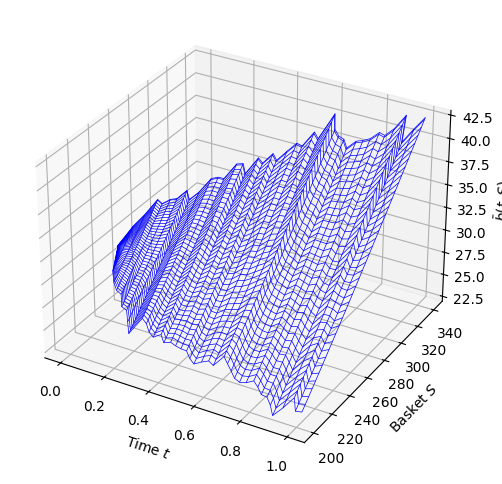

In [39]:
# Step 5: visualize the projected volatility surface
save_plot = True # Set to True to save plots as PNG files
plot_localvol(b_bar, paths, P1, t, K=40, L=150)

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 6: Validate the Markovian projection through terminal log-returns
</h4>

After fitting the projected volatility function $\bar b(t,s)$, we now test whether the corresponding one-dimensional projected process reproduces the terminal distribution of the true basket.

This is the main purpose of the Markovian projection: replace the original high-dimensional basket dynamics by a one-dimensional diffusion that preserves the relevant distributional behavior.

### The two processes being compared

#### 1. The true basket process

The original basket is
$$
S_t = P_1^\top X_t,
$$
where $X_t$ is the correlated $d$-dimensional Black--Scholes process.

#### 2. The projected one-dimensional process

Using the fitted local volatility, we define the projected process
$$
d\bar S_t = r\bar S_t\,dt + \bar b(t,\bar S_t)\,dB_t,
\qquad
\bar S_0=S_0.
$$

If the Markovian projection is accurate, then the law of $\bar S_T$ should be close to the law of the true basket $S_T$.

### Why terminal log-returns?

The function compares the two models using the terminal log-returns
$$
\log\!\left(\frac{S_T}{S_0}\right),
\qquad
\log\!\left(\frac{\bar S_T}{S_0}\right).
$$

This is a natural quantity to compare because:
- it is scale-invariant,
- it is standard in mathematical finance,
- and it captures the terminal distribution in a convenient way.

The code computes both samples and overlays their histograms on the same plot.

### Why this is a good validation

The fitted volatility surface is only useful if it leads to a projected process with the correct terminal behavior.

So this step checks the model **end-to-end**:

- the true basket is simulated directly from the correlated $d$-dimensional dynamics,
- the projected process is simulated using the fitted $\bar b(t,s)$,
- then both terminal distributions are compared visually and through their mean and standard deviation.

If the two distributions are close, that is strong evidence that the regression-based Markovian projection is working well.

### What to look for in the plot

A good result should show:
- substantial overlap between the two histograms,
- similar center,
- similar spread,
- and no obvious tail mismatch.

If the two distributions are noticeably different, that may indicate:
- insufficient training data,
- an overly restrictive polynomial basis,
- or poor extrapolation of $\bar b(t,s)$.

<details>
<summary><strong>View function used (syntax + explanation): plot_logreturns</strong></summary>

**Function:** `plot_logreturns(b_bar, x0, P1, vol, cov_mat, r, dt, N_t, M=10000, save_plot=False)`

**Location:** `L2_Regression/Simple_Polynomials/single_level_production.py`

**What it does:**
- Simulates the projected one-dimensional process using the fitted function `b_bar`.
- Simulates the true correlated basket process.
- Computes terminal log-returns for both models.
- Prints summary statistics such as mean and standard deviation.
- Produces a histogram comparison of the two empirical distributions.

<pre><code>plot_logreturns(b_bar, x0, P1, vol, cov_mat, r, dt, N_t, M=10000, save_plot=False)</code></pre>

</details>

In [27]:
show_full_function(plot_logreturns)

Mean, std of true process: 0.04231199957046249 0.118838977482667
Mean, std of projected process: 0.04346672387728966 0.11733802721150277


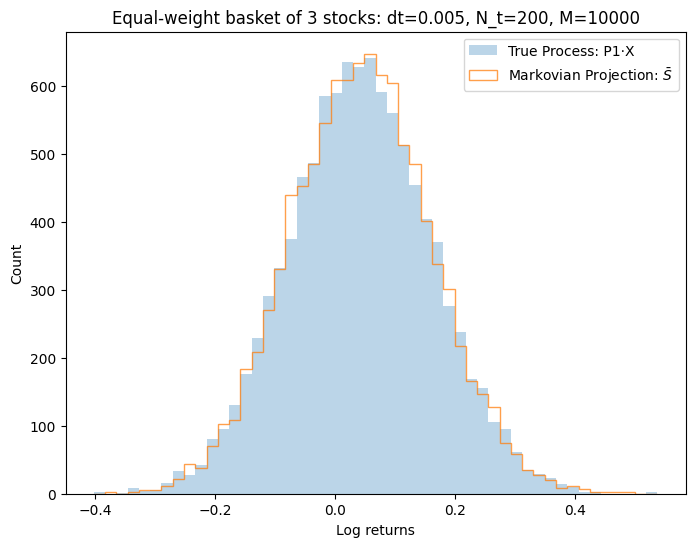

In [29]:
# Step 6: validate the Markovian projection
save_plot = True

plot_logreturns(
    b_bar=b_bar,
    x0=x0,
    P1=P1,
    vol=vol,
    cov_mat=cov_mat,
    r=r,
    dt=dt,
    N_t=N_t,
    M=10000,
    save_plot=save_plot
)

<h2 style="text-align: center; color: #0B63CE; margin-top: 28px;">Weak Error Analysis</h2>

In this section we document the implementation in `Simple_Polynomials/weak_error_analysis.py`.

The stochastic model is the same as in the previous part of the notebook: a correlated $d$-dimensional Black--Scholes basket
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\,(G\,dW(t))_i,\qquad i=1,\dots,d,
$$
with equal-weight basket
$$
S(t)=P_1^\top X(t),\qquad P_1=\frac1d(1,\dots,1)^\top.
$$

As before, we construct a one-dimensional Markovian surrogate
$$
d\bar S(t)=r\bar S(t)\,dt+\bar b(t,\bar S(t))\,dB(t),
\qquad \bar S(0)=S(0),
$$
where the projected volatility $\bar b(t,s)$ is obtained by $L^2$ regression.


The main difference is that the objective is now **weak error analysis**. In the previous part of the notebook, validation was done by comparing the terminal distribution of the true basket with that of the projected process.

Here, instead, we measure how well the projected process reproduces **option prices**, i.e. expectations of payoff functions.  
For a payoff $g$, the weak error is
$$
\varepsilon_{\mathrm{weak}}
=
\frac{\left|\mathbb{E}[g(S_T)]-\mathbb{E}[g(\bar S_T)]\right|}{\left|\mathbb{E}[g(S_T)]\right|}.
$$

In the reference implementation, the payoff is a European call with strike equal to the initial basket value:
$$
g(x)=(x-K)^+,\qquad K=S_0=P_1^\top x_0.
$$

So the quantity being estimated is
$$
\varepsilon_{\mathrm{weak}}
=
\frac{\left|\mathbb{E}\big[(S_T-K)^+\big]-\mathbb{E}\big[(\bar S_T-K)^+\big]\right|}{\left|\mathbb{E}\big[(S_T-K)^+\big]\right|}.
$$

For pricing purposes, matching the full pathwise behavior of the basket is not necessary.  
What matters is whether the projected model reproduces expectations of relevant payoff functions.

This is precisely the meaning of **weak approximation**:
- we do not require pathwise agreement,
- we require agreement at the level of expectations.

So this section provides a more quantitative validation of the Markovian projection than the previous histogram comparison.


## Approximation space used here

Although the model is the same, the regression setting is slightly simplified in this weak-error implementation.

Instead of the basis
$$
\{1,\ s_c,\ s_c^2,\ t_c\},
$$
used in `single_level_production.py`, the weak-error file uses the reduced basis
$$
\{1,\ s_c,\ t_c\},
$$
corresponding to the index pairs
$$
(0,0),\ (0,1),\ (1,0).
$$

Thus, in this section the projected variance is approximated by
$$
\tilde b^2(t,s)=c_0+c_1 s_c+c_2 t_c,
$$
where
$$
t_c=\frac{t-\mu_t}{\sigma_t},
\qquad
s_c=\frac{s-\mu_s}{\sigma_s}.
$$

This reduction makes the regression cheaper and is consistent with the purpose of this file: repeated weak-error experiments across many validation sample sizes.

## Numerical setting

The implementation keeps the same market parameters as before, but changes the numerical setup:

- a reduced regression basis,
- more training paths for the fit,
- and multiple validation sample sizes
  $$
  M\in\{2000,4000,8000,16000,32000,64000\},
  $$
  in order to study how the weak error behaves as Monte Carlo sampling increases.

So this part of the notebook should be understood as a **variant of the same example**, specialized for quantitative weak-error verification.

In [41]:
# Basket parameters
d = 3
P1 = np.ones(d) / d

# Reduced polynomial basis: {1, s, t}
pairs_we = [(0, 0), (0, 1), (1, 0)]
P_we = len(pairs_we)

# Market parameters
r = 0.05
x0 = np.linspace(225, 275, num=d)[:, np.newaxis]
vol = np.array([0.2, 0.15, 0.1])
cov_mat = np.array([
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.1],
    [0.3, 0.1, 1.0]
])

# Simulation parameters
dt = 0.005
N_t = 200
M_t_we = 400

# Validation sample sizes for weak error study
M_samples = [2000, 4000, 8000, 16000, 32000, 64000]

t_we = np.linspace(0, N_t * dt, num=N_t)

# Generate training paths
paths_we = we_GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t_we)

print("\n--- Weak Error Analysis: Step 1 summary ---")
print("d =", d)
print("P1 =", P1)
print("basis pairs =", pairs_we)
print("number of basis functions =", P_we)
print("M_t_we =", M_t_we)
print("M_samples =", M_samples)
print("paths_we shape =", paths_we.shape)
print("time grid shape =", t_we.shape)
print("first path, first time step =", paths_we[0, 0, :])


--- Weak Error Analysis: Step 1 summary ---
d = 3
P1 = [0.33333333 0.33333333 0.33333333]
basis pairs = [(0, 0), (0, 1), (1, 0)]
number of basis functions = 3
M_t_we = 400
M_samples = [2000, 4000, 8000, 16000, 32000, 64000]
paths_we shape = (400, 200, 3)
time grid shape = (200,)
first path, first time step = [222.6884402  247.00879598 271.59074357]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 1: Build the regression matrix $D$ and the response vector $\psi$
</h4>

After generating the training paths for the weak-error setting, we now construct the discrete regression problem used to fit the projected variance.

As in the previous part of the notebook, the goal is to approximate
$$
\bar b^2(t,s)
\approx
\sum_{p=1}^{P} c_p\,\psi_p(t,s),
$$
but in this section we use the reduced basis
$$
\{1,\ s_c,\ t_c\},
$$
corresponding to
$$
(0,0),\ (0,1),\ (1,0).
$$

Thus the fitted projected variance has the form
$$
\tilde b^2(t,s)=c_0+c_1 s_c+c_2 t_c,
$$
where
$$
t_c=\frac{t-\mu_t}{\sigma_t},
\qquad
s_c=\frac{s-\mu_s}{\sigma_s}.
$$

### Design matrix

For each path $m$ and time index $n$, let
$$
S^{(m)}(t_n)=P_1^\top X^{(m)}(t_n)
$$
be the basket value.

Flattening all path-time pairs into a single index gives the design matrix
$$
D\in\mathbb{R}^{(M_tN_t)\times P},
$$
whose entries are the basis functions evaluated at the simulated points:
$$
D_{k,p}=\psi_p(t_n,S^{(m)}(t_n)).
$$

So each row corresponds to one training observation, and each column to one basis function.

### Response vector

The target vector
$$
\psi\in\mathbb{R}^{M_tN_t}
$$
contains the true instantaneous basket variance.

For the correlated Black--Scholes basket with equal weights,
$$
\psi_{m,n}
=
\frac{1}{d^2}
\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,\Sigma_{ij}.
$$

This vector is the right-hand side of the discrete least-squares problem
$$
\min_{c\in\mathbb{R}^{P}}\|Dc-\psi\|_2^2.
$$

### Why this step is unchanged mathematically

The weak-error section changes the **purpose of validation**, but not the mathematical meaning of the regression target.

We are still fitting the projected variance from simulated basket data.  
The only real differences here are:
- a reduced basis,
- and the use of more training paths.

The scaling parameters returned in this step will again be needed later when evaluating the fitted projected volatility.

<details>
<summary><strong>View function used (syntax + explanation): normaleq_components</strong></summary>

**Function:** `normaleq_components(paths, P1, pairs, dt, cov_mat, vol)`

**Location:** `L2_Regression/Simple_Polynomials/weak_error_analysis.py`

**What it does:**
- Computes basket values along all simulated paths.
- Rescales time and basket values using empirical mean and standard deviation.
- Builds the design matrix $D$ using the reduced monomial basis.
- Computes the response vector $\psi$ as the true instantaneous basket variance.
- Returns `D`, `psi`, and the scaling parameters.

<pre><code>D_we, psi_we, scalers_we = we_normaleq_components(paths_we, P1, pairs_we, dt, cov_mat, vol)</code></pre>

</details>

In [42]:
# Weak Error Analysis — Step 2: build regression matrix and response vector
D_we, psi_we, scalers_we = we_normaleq_components(paths_we, P1, pairs_we, dt, cov_mat, vol)

t_mean_we, t_std_we, s_mean_we, s_std_we = scalers_we

print("\n--- Weak Error Analysis: Step 2 summary ---")
print("D_we shape:", D_we.shape)
print("psi_we shape:", psi_we.shape)
print("scalers_we =", scalers_we)
print("first row of D_we:", D_we[0])
print("first entries of psi_we:", psi_we[:5].ravel())


--- Weak Error Analysis: Step 2 summary ---
D_we shape: (80000, 3)
psi_we shape: (80000, 1)
scalers_we = (np.float64(0.5), np.float64(0.29012213681716326), np.float64(255.36461403838484), np.float64(21.638252369884935))
first row of D_we: [ 1.         -0.38212979 -1.7234121 ]
first entries of psi_we: [851.25852767 841.36898966 845.75389689 863.59107018 865.00158855]


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 2: Fit the regression coefficients and construct the projected volatility
</h4>

Once the design matrix $D$ and the response vector $\psi$ have been built, we solve the discrete least-squares problem
$$
\min_{c\in\mathbb{R}^{P}} \|Dc-\psi\|_2^2,
$$
where $c=(c_1,\dots,c_P)$ is the vector of coefficients of the polynomial approximation.

In this weak-error setting, the reduced basis is
$$
\{1,\ s_c,\ t_c\},
$$
so the fitted projected variance has the form
$$
\tilde b^2(t,s)=c_0+c_1 s_c+c_2 t_c.
$$

### Step 2a: Fit the coefficients

The least-squares system is solved with QR decomposition:
$$
D=QR
\quad\Longrightarrow\quad
Rc = Q^\top \psi.
$$

This gives the coefficient vector $c$ defining the fitted approximation of the projected variance.

### Step 2b: Build the projected volatility function

After computing $c$, we define the projected local volatility by
$$
\bar b(t,s)=\sqrt{\tilde b^2(t,s)}.
$$

That means:
1. given a point $(t,s)$,
2. we first rescale it using the same normalization as in the regression,
3. we evaluate the fitted polynomial,
4. then we take the square root.

In this weak-error implementation, the function is made **vectorization-compatible**, because later it must be evaluated on large arrays during the Monte Carlo weak-error study.

So this step converts the fitted coefficients into the actual function used in the projected SDE
$$
d\bar S_t = r\bar S_t\,dt+\bar b(t,\bar S_t)\,dB_t.
$$

<details>
<summary><strong>View function used (syntax + explanation): fit_local_vol</strong></summary>

**Function:** `fit_local_vol(D, psi)`

**Location:** `L2_Regression/Simple_Polynomials/weak_error_analysis.py`

**What it does:**
- Solves the least-squares problem
  $$
  \min_c \|Dc-\psi\|_2^2
  $$
  using QR decomposition.
- Returns the fitted coefficient vector `c`.

<pre><code>c_we = we_fit_local_vol(D_we, psi_we)</code></pre>

</details>

<details>
<summary><strong>View function used (syntax + explanation): make_b_bar</strong></summary>

**Function:** `make_b_bar(c, pairs, t_mean, t_std, s_mean, s_std)`

**Location:** `L2_Regression/Simple_Polynomials/weak_error_analysis.py`

**What it does:**
- Builds a callable function `b_bar(t, S)` from the fitted coefficients.
- Rescales inputs using the same mean/std normalization used during regression.
- Evaluates the fitted polynomial approximation of the projected variance.
- Returns the projected volatility using `np.sqrt(...)`, which makes the function compatible with vectorized Monte Carlo simulation.

<pre><code>b_bar_we = we_make_b_bar(c_we, pairs_we, t_mean_we, t_std_we, s_mean_we, s_std_we)</code></pre>

</details>

In [43]:
# Weak Error Analysis — Step 2: fit coefficients + build projected volatility
c_we = we_fit_local_vol(D_we, psi_we)
b_bar_we = we_make_b_bar(c_we, pairs_we, t_mean_we, t_std_we, s_mean_we, s_std_we)

print("\n--- Weak Error Analysis: Step 3 summary ---")
print("c_we shape:", c_we.shape)
print("coefficients =", c_we)
print("b_bar_we callable created:", callable(b_bar_we))

# Quick sanity checks
test_points_we = [
    (t_we[0], float(np.mean(paths_we[:, 0, :].dot(P1)))),
    (t_we[len(t_we)//2], float(np.mean(paths_we[:, len(t_we)//2, :].dot(P1)))),
    (t_we[-1], float(np.mean(paths_we[:, -1, :].dot(P1))))
]

for t_test, s_test in test_points_we:
    print(f"b_bar_we({t_test:.3f}, {s_test:.3f}) = {b_bar_we(t_test, s_test):.6f}")


--- Weak Error Analysis: Step 3 summary ---
c_we shape: (3,)
coefficients = [9.19111585e+02 1.95072597e+02 8.79225190e-01]
b_bar_we callable created: True
b_bar_we(0.000, 249.978) = 29.479422
b_bar_we(0.503, 255.160) = 30.286532
b_bar_we(1.000, 261.647) = 31.261152


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 3: Visualize the projected volatility surface
</h4>

After fitting the coefficients and constructing the projected volatility function $\bar b(t,s)$, it is useful to inspect the resulting surface before running the weak-error experiment.

At this stage, we have a deterministic function
$$
(t,s)\longmapsto \bar b(t,s),
$$
which defines the local volatility of the one-dimensional projected process.

The purpose of this step is to verify visually that the fitted projected volatility behaves reasonably over the region explored by the training data.

### Plotting region

As in the previous section, we do not plot the function on an arbitrary rectangle.  
Instead, we use the simulated basket values
$$
S^{(m)}(t_n)=P_1^\top X^{(m)}(t_n)
$$
to determine realistic lower and upper bounds at each time level.

This keeps the visualization focused on the domain where the regression is actually informed by the data.

<details>
<summary><strong>View function used (syntax + explanation): plot_localvol</strong></summary>

**Function:** `plot_localvol(b_bar, paths, P1, t, K=40, L=150)`

**Location:** `L2_Regression/Simple_Polynomials/weak_error_analysis.py`

**What it does:**
- Uses the simulated basket paths to determine a realistic plotting domain.
- Evaluates the projected volatility on a time/basket grid.
- Produces a 3D wireframe plot of the fitted local volatility surface.
- Returns the basket domain used for the plot.

<pre><code>domain_we = we_plot_localvol(b_bar_we, paths_we, P1, t_we, K=40, L=150)</code></pre>

</details>

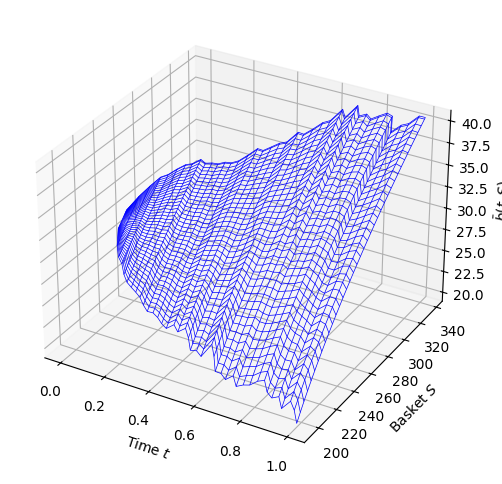


--- Weak Error Analysis: Step 4 summary ---
domain_we returned: True
number of domain arrays: 2
s_min shape: (200,)
s_max shape: (200,)


In [44]:
# Weak Error Analysis — Step 4: visualize the projected volatility surface
domain_we = we_plot_localvol(b_bar_we, paths_we, P1, t_we, K=40, L=150)

print("\n--- Weak Error Analysis: Step 4 summary ---")
print("domain_we returned:", isinstance(domain_we, tuple))
print("number of domain arrays:", len(domain_we))
print("s_min shape:", domain_we[0].shape)
print("s_max shape:", domain_we[1].shape)

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 4: Perform the weak error analysis
</h4>

We now reach the main goal of this section: measuring how well the projected one-dimensional process reproduces option prices of the true basket model.

Let
$$
g(x)=(x-K)^+
$$
be the payoff of a European call option, where the strike is chosen as the initial basket value
$$
K=S_0=P_1^\top x_0.
$$

The weak error compares the expected payoff under:
- the true basket process $S_T$,
- the projected process $\bar S_T$.

It is defined by
$$
\varepsilon_{\mathrm{weak}}
=
\frac{\left|\mathbb{E}\big[g(S_T)\big]-\mathbb{E}\big[g(\bar S_T)\big]\right|}{\left|\mathbb{E}\big[g(S_T)\big]\right|}.
$$

For the call payoff used here, this becomes
$$
\varepsilon_{\mathrm{weak}}
=
\frac{\left|\mathbb{E}\big[(S_T-K)^+\big]-\mathbb{E}\big[(\bar S_T-K)^+\big]\right|}{\left|\mathbb{E}\big[(S_T-K)^+\big]\right|}.
$$

### What is being tested?

The function does not compute the weak error for just one Monte Carlo sample size.  
Instead, it studies the behavior of the weak error for a sequence of validation sample sizes
$$
M\in\{2000,4000,8000,16000,32000,64000\}.
$$

For each value of $M$:
1. the projected process is simulated,
2. the true basket process is simulated,
3. the corresponding call prices are estimated,
4. the relative weak error is computed.

This is repeated over several independent trials, so that we can also estimate:
- the mean weak error,
- the variability of the weak error.

### Expected behavior

If the projected model is good, then the weak error should be small.  
As the number of validation paths $M$ increases, the Monte Carlo noise decreases, so the observed weak error should stabilize.

Typically:
- for smaller $M$, Monte Carlo sampling error dominates,
- for larger $M$, the observed error approaches the intrinsic regression/model error.

Thus, the weak-error curve helps separate:
- Monte Carlo error,
- regression approximation error.

### Output of this step

The function:
- computes weak errors for all chosen sample sizes,
- repeats the experiment several times,
- saves the raw results to a CSV file,
- and plots the weak error as a function of the validation sample size.

This gives both a visual and a quantitative picture of the quality of the projected model.

<details>
<summary><strong>View function used (syntax + explanation): plot_weakerror</strong></summary>

**Function:** `plot_weakerror(b_bar, x0, P1, vol, cov_mat, r, dt, N_t, M_samples)`

**Location:** `L2_Regression/Simple_Polynomials/weak_error_analysis.py`

**What it does:**
- Simulates the projected one-dimensional process for several Monte Carlo sample sizes.
- Simulates the true basket process for the same sample sizes.
- Computes European call option prices under both models.
- Evaluates the relative weak error for each trial and each sample size.
- Saves the weak error data to `weak_errors_by_M.csv`.
- Produces a weak-error plot with scatter points and mean/std error bars.

<pre><code>plot_weakerror(b_bar_we, x0, P1, vol, cov_mat, r, dt, N_t, M_samples)</code></pre>

</details>

This step may take several minutes...
Completed 10 trials for M = 2000
Completed 10 trials for M = 4000
Completed 10 trials for M = 8000
Completed 10 trials for M = 16000
Completed 10 trials for M = 32000
Completed 10 trials for M = 64000

Results saved to 'weak_errors_by_M.csv'


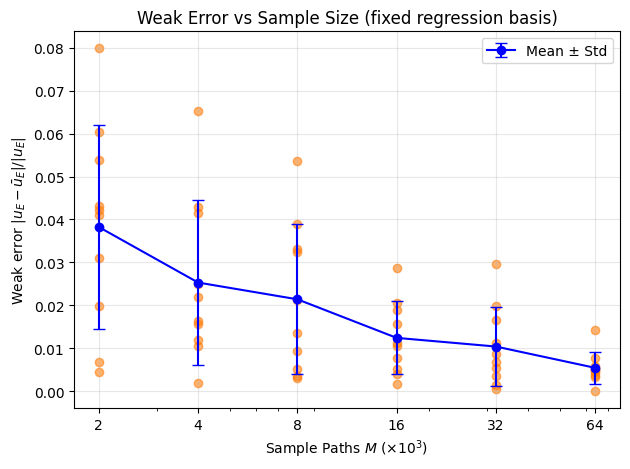

In [45]:
# Weak Error Analysis — Step 5: run the weak error experiment
print("This step may take several minutes...")

plot_weakerror(
    b_bar=b_bar_we,
    x0=x0,
    P1=P1,
    vol=vol,
    cov_mat=cov_mat,
    r=r,
    dt=dt,
    N_t=N_t,
    M_samples=M_samples
)

In [46]:
show_full_function(plot_weakerror)